In [1]:
import pandas as pd
import missingno
import numpy as np
import matplotlib.pyplot as plt

import sys

sys.path.insert(0, "../../../Modules")

from utils import *

enc = 'utf-8' 
dec = 'greek8'

In [2]:
import warnings
warnings.filterwarnings('ignore')

In [3]:
raw_data_2021 = pd.read_csv('../data/GR_WNV_cases_2010-2021.csv', encoding = enc)
raw_data_2021.head(5)

,αα,Id διαχείρισης δεδομένων,Έτος,Ηλικία \n(σε έτη),Φύλο,Ημ/νία έναρξης συμπτωμάτων,Προσβολή ΚΝΣ (ΝΑΙ/ΟΧΙ),Περιφέρεια πιθανής έκθεσης,Περιφερειακή ενότητα πιθανής έκθεσης,Δήμος πιθανής έκθεσης,Πόλη/χωριό (/συνοικία Αθήνας) πιθανής έκθεσης,Κωδικός κανάβου κελιού 1x1 χλμ πιθανής έκθεσης,Unnamed: 12
0,1.0,3.0,2010.0,75.0,ΘΗΛΥ,28-07-10,NAI,Κεντρικής Μακεδονίας,Θεσσαλονίκης,Θεσσαλονίκης,"Παπάφη, Θεσσαλονίκη",NaN,NaN
1,2.0,17.0,2010.0,78.0,ΑΡΡΕΝ,22-07-10,NAI,Κεντρικής Μακεδονίας,Ημαθίας,Βέροιας,Βέροια,NaN,NaN
2,3.0,4.0,2010.0,70.0,ΘΗΛΥ,24-07-10,NAI,Κεντρικής Μακεδονίας,Κιλκίς,Κιλκίς,Λεβεντοχώρι,NaN,NaN
3,4.0,21.0,2010.0,74.0,ΑΡΡΕΝ,30-7-2010,NAI,Κεντρικής Μακεδονίας,Κιλκίς,Κιλκίς,Καμπάνη,NaN,NaN
4,5.0,59.0,2010.0,19.0,ΘΗΛΥ,06-07-10,NAI,Κεντρικής Μακεδονίας,Σερρών,Ηράκλειας,Ποντισμένο,NaN,NaN


In [4]:
raw_data_2022 = pd.read_csv('../data/GR_WNV_cases_2022.csv', encoding = enc)
raw_data_2022.head(5)

,Έτος,Ημ/νία έναρξης συμπτωμάτων,Περιφέρεια πιθανής έκθεσης,Περιφερειακή ενότητα πιθανής έκθεσης,Δήμος πιθανής έκθεσης,Αριθμός ασθενών ΜΕ εκδηλώσεις από το ΚΝΣ,Αριθμός ασθενών ΧΩΡΙΣ εκδηλώσεις από το ΚΝΣ,Συνολικός αριθμός ασθενών
0,2022,12-07-22,Κεντρικής Μακεδονίας,Θεσσαλονίκης,Αμπελοκήπων - Μενεμένης,1,0,1
1,2022,19-07-22,Κεντρικής Μακεδονίας,Θεσσαλονίκης,Δέλτα,2,0,2
2,2022,19-07-22,Κεντρικής Μακεδονίας,Θεσσαλονίκης,Χαλκηδόνος,1,0,1
3,2022,16-07-22,Κεντρικής Μακεδονίας,Θεσσαλονίκης,Δέλτα,1,0,1
4,2022,16-07-22,Κεντρικής Μακεδονίας,Θεσσαλονίκης,Θέρμης,1,0,1


In [5]:
raw_data_2023 = pd.read_csv('../data/GR_WNV_cases_2023.csv', encoding = enc)
raw_data_2023.head(5)

,Έτος,Ημ/νία έναρξης συμπτωμάτων,Περιφέρεια πιθανής έκθεσης,Περιφερειακή ενότητα πιθανής έκθεσης,Δήμος πιθανής έκθεσης,Αριθμός ασθενών ΜΕ εκδηλώσεις από το ΚΝΣ,Αριθμός ασθενών ΧΩΡΙΣ εκδηλώσεις από το ΚΝΣ,Συνολικός αριθμός ασθενών
0,2023,17-10-23,Πελοποννήσου,Αργολίδας,Άργους - Μυκηνών,1,0,1
1,2023,14-08-23,Ηπείρου,Άρτας,Αρταίων,2,0,2
2,2023,29-08-23,Ηπείρου,Άρτας,Αρταίων,1,1,2
3,2023,29-08-23,Ηπείρου,Άρτας,Νικολάου Σκουφά,1,0,1
4,2023,17-10-23,Δυτικής Ελλάδας,Αχαΐας,Αιγιαλείας,1,0,1


In [6]:
raw_data_2021.shape

(1421, 13)

In [7]:
raw_data_2022.shape

(177, 8)

In [8]:
raw_data_2023.shape

(125, 8)

In [11]:
data_2021 = raw_data_2021.set_axis(['idx', 'id', 'year', 'age', 'sex', 'onset of symptoms', 'cns attack', 'nuts2', 'nuts3', 'lau1', 'lau2', 'cell_code', 'unnamed'], axis=1)
data_2022 = raw_data_2022.set_axis(['year', 'onset of symptoms', 'nuts2', 'nuts3', 'lau1', 'cases_CNS', 'cases_WO_CNS', 'cases'], axis=1)
data_2023 = raw_data_2023.set_axis(['year', 'onset of symptoms', 'nuts2', 'nuts3', 'lau1', 'cases_CNS', 'cases_WO_CNS', 'cases'], axis=1)

In [12]:
data_2021.drop(columns = ['idx', 'id', 'cell_code', 'unnamed'], inplace = True)
data_2021.dropna(axis = 0, subset = ['onset of symptoms', 'lau1'], how = 'any', inplace = True)
data_2021['onset of symptoms'] = data_2021['onset of symptoms'].apply(lambda x : x.replace("~", ""))
data_2021 = data_2021[data_2021['onset of symptoms'] != 'Άγνωστη']
data_2021 = data_2021[data_2021['nuts2'] != 'Άγνωστη']
data_2021 = data_2021[data_2021['nuts2'] != 'Απροσδιόριστη']
data_2021 = data_2021[data_2021['nuts2'] != 'Απροσδιόριστη (Ανατολικής Μακεδονίας & Θράκης Ή Κεντρικής Μακεδονίας)']
data_2021['onset of symptoms'] = pd.to_datetime(data_2021['onset of symptoms'], dayfirst=True, errors='coerce')
data_2021['cases'] = 1
data_2021 = data_2021.astype({"year":'int'})

In [13]:
data_2021.drop(columns = ['age', 'sex', 'cns attack', 'lau1', 'lau2'], inplace = True)


In [14]:
data_2021

,year,onset of symptoms,nuts2,nuts3,cases
0,2010,2010-07-28,Κεντρικής Μακεδονίας,Θεσσαλονίκης,1
1,2010,2010-07-22,Κεντρικής Μακεδονίας,Ημαθίας,1
2,2010,2010-07-24,Κεντρικής Μακεδονίας,Κιλκίς,1
3,2010,2010-07-30,Κεντρικής Μακεδονίας,Κιλκίς,1
4,2010,2010-07-06,Κεντρικής Μακεδονίας,Σερρών,1
...,...,...,...,...,...
1414,2021,2021-08-31,Ανατολικής Μακεδονίας & Θράκης,Καβάλας,1
1415,2021,2021-09-13,Κεντρικής Μακεδονίας,Ημαθίας,1
1416,2021,2021-09-03,Κεντρικής Μακεδονίας,Ημαθίας,1
1418,2021,2021-10-04,Κεντρικής Μακεδονίας,Θεσσαλονίκης,1


In [15]:
data_2022.drop(columns = ['lau1', 'cases_CNS', 'cases_WO_CNS'], inplace = True)
data_2022['onset of symptoms'] = pd.to_datetime(data_2022['onset of symptoms'], dayfirst=True, errors='coerce')

In [16]:
data_2023.drop(columns = ['lau1', 'cases_CNS', 'cases_WO_CNS'], inplace = True)
data_2023['onset of symptoms'] = pd.to_datetime(data_2023['onset of symptoms'], dayfirst=True, errors='coerce')

In [17]:
data_2022

,year,onset of symptoms,nuts2,nuts3,cases
0,2022,2022-07-12,Κεντρικής Μακεδονίας,Θεσσαλονίκης,1
1,2022,2022-07-19,Κεντρικής Μακεδονίας,Θεσσαλονίκης,2
2,2022,2022-07-19,Κεντρικής Μακεδονίας,Θεσσαλονίκης,1
3,2022,2022-07-16,Κεντρικής Μακεδονίας,Θεσσαλονίκης,1
4,2022,2022-07-16,Κεντρικής Μακεδονίας,Θεσσαλονίκης,1
...,...,...,...,...,...
172,2022,2022-10-18,Θεσσαλίας,Λάρισας,1
173,2022,2022-10-18,Ανατολικής Μακεδονίας και Θράκης,Δράμας,1
174,2022,2022-10-18,Ιονίων Νήσων,Λευκάδας,1
175,2022,2022-10-25,Κεντρικής Μακεδονίας,Θεσσαλονίκης,1


In [18]:
data_2023

,year,onset of symptoms,nuts2,nuts3,cases
0,2023,2023-10-17,Πελοποννήσου,Αργολίδας,1
1,2023,2023-08-14,Ηπείρου,Άρτας,2
2,2023,2023-08-29,Ηπείρου,Άρτας,2
3,2023,2023-08-29,Ηπείρου,Άρτας,1
4,2023,2023-10-17,Δυτικής Ελλάδας,Αχαΐας,1
...,...,...,...,...,...
120,2023,2023-10-10,Θεσσαλίας,Τρικάλων,1
121,2023,2023-09-05,Κεντρικής Μακεδονίας,Χαλκιδικής,1
122,2023,2023-09-12,Κεντρικής Μακεδονίας,Χαλκιδικής,1
123,2023,2023-09-19,Κεντρικής Μακεδονίας,Χαλκιδικής,3


In [19]:
data_2021.cases.unique()


array([1], dtype=int64)

In [20]:
data_2022.cases.unique()

array([ 1,  2,  4,  3,  6,  5, 10], dtype=int64)

In [21]:
data_2023.cases.unique()

array([1, 2, 5, 3, 4], dtype=int64)

In [22]:
data_2021_grouped = data_2021.groupby(['year', 'onset of symptoms',	'nuts2', 'nuts3'], as_index = False)
data_2021 = data_2021_grouped.sum()

In [23]:
data_2021.cases.unique()

array([1, 2, 3, 4, 5, 6], dtype=int64)

In [24]:
data_2021.head()

,year,onset of symptoms,nuts2,nuts3,cases
0,2010,2010-07-06,Κεντρικής Μακεδονίας,Σερρών,1
1,2010,2010-07-16,Κεντρικής Μακεδονίας,Κιλκίς,1
2,2010,2010-07-18,Κεντρικής Μακεδονίας,Πέλλας,1
3,2010,2010-07-19,Κεντρικής Μακεδονίας,Θεσσαλονίκης,2
4,2010,2010-07-20,Κεντρικής Μακεδονίας,Ημαθίας,1


In [25]:
data_2022.head()

,year,onset of symptoms,nuts2,nuts3,cases
0,2022,2022-07-12,Κεντρικής Μακεδονίας,Θεσσαλονίκης,1
1,2022,2022-07-19,Κεντρικής Μακεδονίας,Θεσσαλονίκης,2
2,2022,2022-07-19,Κεντρικής Μακεδονίας,Θεσσαλονίκης,1
3,2022,2022-07-16,Κεντρικής Μακεδονίας,Θεσσαλονίκης,1
4,2022,2022-07-16,Κεντρικής Μακεδονίας,Θεσσαλονίκης,1


In [26]:
data_2023.head()

,year,onset of symptoms,nuts2,nuts3,cases
0,2023,2023-10-17,Πελοποννήσου,Αργολίδας,1
1,2023,2023-08-14,Ηπείρου,Άρτας,2
2,2023,2023-08-29,Ηπείρου,Άρτας,2
3,2023,2023-08-29,Ηπείρου,Άρτας,1
4,2023,2023-10-17,Δυτικής Ελλάδας,Αχαΐας,1


In [27]:
data = pd.concat([data_2021,data_2022,data_2023], ignore_index=True)

In [28]:
data

,year,onset of symptoms,nuts2,nuts3,cases
0,2010,2010-07-06,Κεντρικής Μακεδονίας,Σερρών,1
1,2010,2010-07-16,Κεντρικής Μακεδονίας,Κιλκίς,1
2,2010,2010-07-18,Κεντρικής Μακεδονίας,Πέλλας,1
3,2010,2010-07-19,Κεντρικής Μακεδονίας,Θεσσαλονίκης,2
4,2010,2010-07-20,Κεντρικής Μακεδονίας,Ημαθίας,1
...,...,...,...,...,...
1426,2023,2023-10-10,Θεσσαλίας,Τρικάλων,1
1427,2023,2023-09-05,Κεντρικής Μακεδονίας,Χαλκιδικής,1
1428,2023,2023-09-12,Κεντρικής Μακεδονίας,Χαλκιδικής,1
1429,2023,2023-09-19,Κεντρικής Μακεδονίας,Χαλκιδικής,3


In [29]:
data.dropna(axis = 0, subset = ['onset of symptoms'], how = 'any', inplace = True)

In [30]:
data.reset_index(drop=True, inplace=True)

In [31]:
data

,year,onset of symptoms,nuts2,nuts3,cases
0,2010,2010-07-06,Κεντρικής Μακεδονίας,Σερρών,1
1,2010,2010-07-16,Κεντρικής Μακεδονίας,Κιλκίς,1
2,2010,2010-07-18,Κεντρικής Μακεδονίας,Πέλλας,1
3,2010,2010-07-19,Κεντρικής Μακεδονίας,Θεσσαλονίκης,2
4,2010,2010-07-20,Κεντρικής Μακεδονίας,Ημαθίας,1
...,...,...,...,...,...
1426,2023,2023-10-10,Θεσσαλίας,Τρικάλων,1
1427,2023,2023-09-05,Κεντρικής Μακεδονίας,Χαλκιδικής,1
1428,2023,2023-09-12,Κεντρικής Μακεδονίας,Χαλκιδικής,1
1429,2023,2023-09-19,Κεντρικής Μακεδονίας,Χαλκιδικής,3


<Axes: >

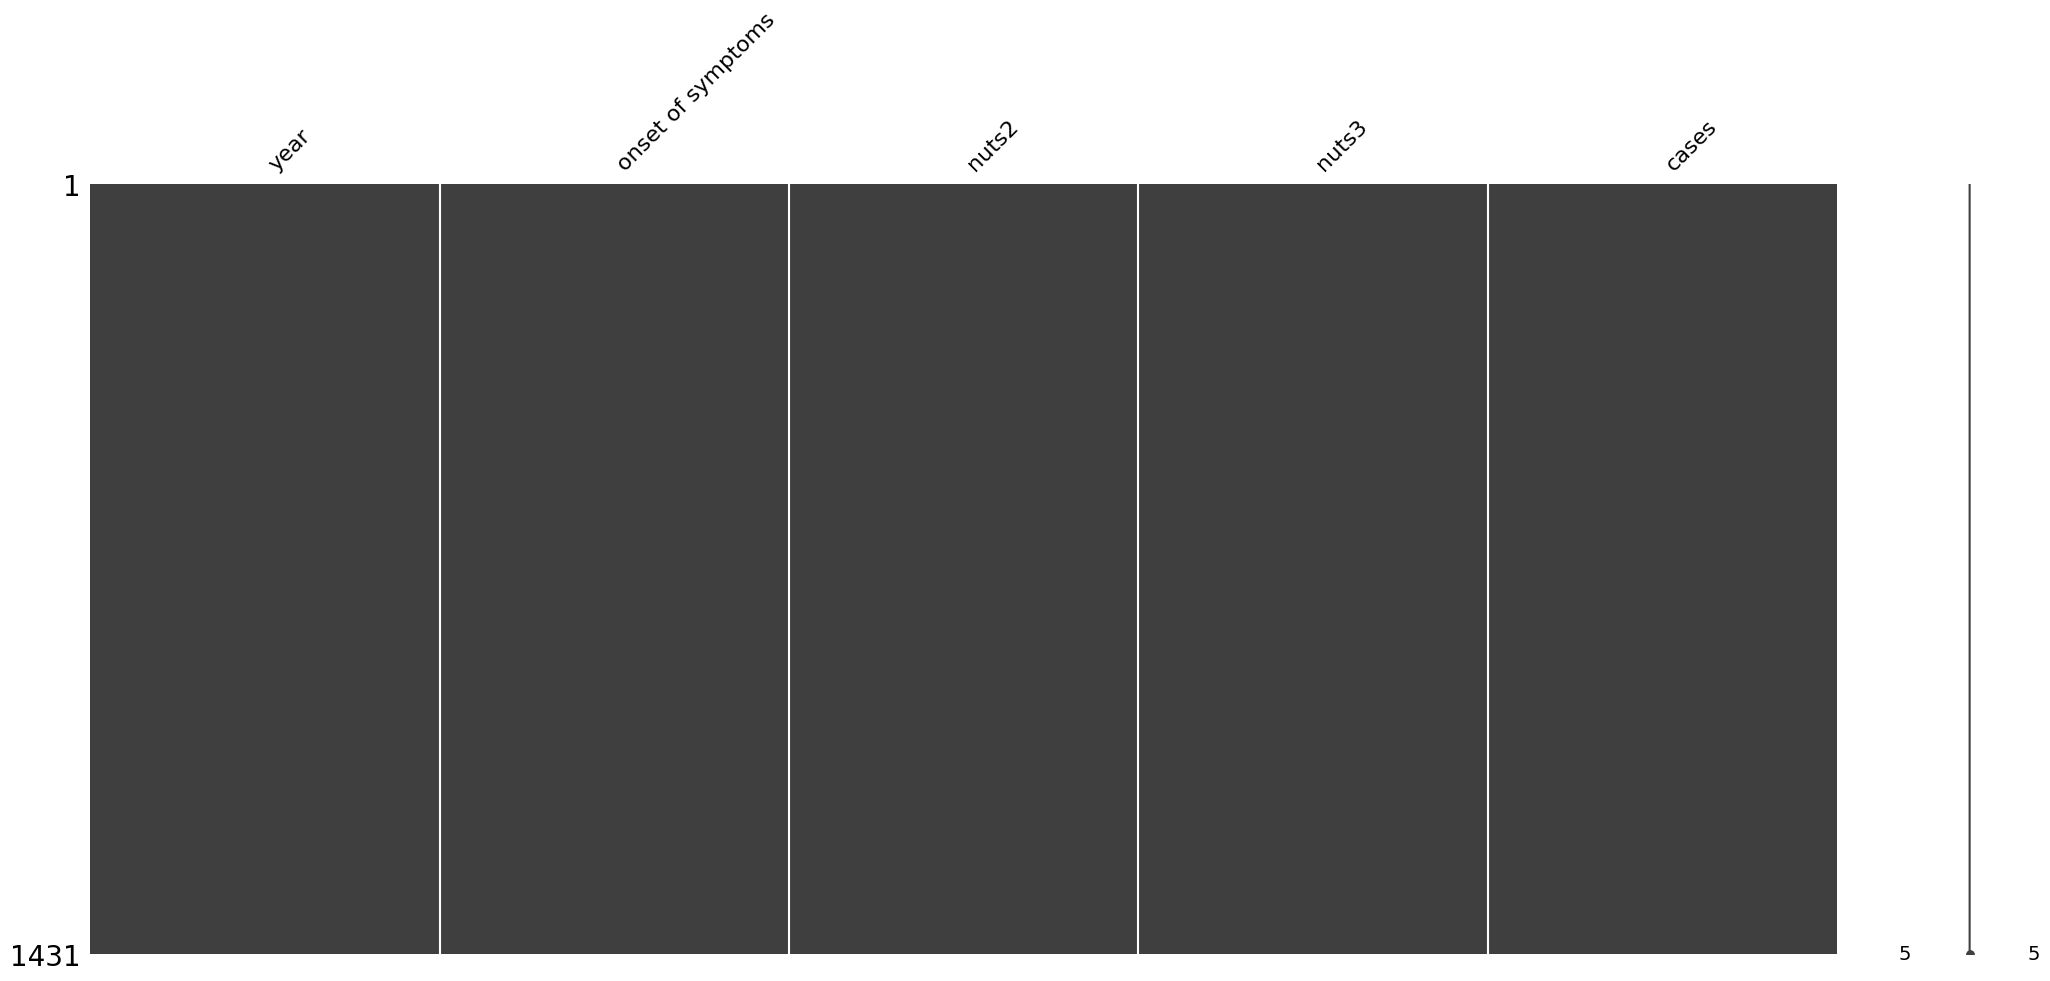

In [32]:
missingno.matrix(data)

In [33]:
data.cases.unique()

array([ 1,  2,  3,  4,  5,  6, 10], dtype=int64)

In [34]:
process_greek(data, 'nuts2')
process_greek(data, 'nuts3')

data['day'] = data['onset of symptoms'].apply(lambda x : x.day)
data['month'] = data['onset of symptoms'].apply(lambda x : x.month)

In [35]:
data = data.reindex(columns=['onset of symptoms', 'year', 'month', 'day', 'nuts2', 'nuts3', 'cases'])

In [36]:
data

,onset of symptoms,year,month,day,nuts2,nuts3,cases
0,2010-07-06,2010,7,6,κεντρικης μακεδονιας,σερρων,1
1,2010-07-16,2010,7,16,κεντρικης μακεδονιας,κιλκις,1
2,2010-07-18,2010,7,18,κεντρικης μακεδονιας,πελλας,1
3,2010-07-19,2010,7,19,κεντρικης μακεδονιας,θεσσαλονικης,2
4,2010-07-20,2010,7,20,κεντρικης μακεδονιας,ημαθιας,1
...,...,...,...,...,...,...,...
1426,2023-10-10,2023,10,10,θεσσαλιας,τρικαλων,1
1427,2023-09-05,2023,9,5,κεντρικης μακεδονιας,χαλκιδικης,1
1428,2023-09-12,2023,9,12,κεντρικης μακεδονιας,χαλκιδικης,1
1429,2023-09-19,2023,9,19,κεντρικης μακεδονιας,χαλκιδικης,3


In [37]:
data.to_csv("../data/GR_WNV_cases_2010-2023_processed.csv", encoding = enc, index = False)

In [38]:
data = convert_multiple_cases(data, target_col = 'cases')

In [39]:
data

,onset of symptoms,year,month,day,nuts2,nuts3,cases
0,2010-07-06,2010,7,6,κεντρικης μακεδονιας,σερρων,1
1,2010-07-16,2010,7,16,κεντρικης μακεδονιας,κιλκις,1
2,2010-07-18,2010,7,18,κεντρικης μακεδονιας,πελλας,1
3,2010-07-19,2010,7,19,κεντρικης μακεδονιας,θεσσαλονικης,1
4,2010-07-20,2010,7,20,κεντρικης μακεδονιας,ημαθιας,1
...,...,...,...,...,...,...,...
1825,2022-09-20,2022,9,20,θεσσαλιας,λαρισας,1
1826,2022-09-20,2022,9,20,θεσσαλιας,λαρισας,1
1827,2022-09-20,2022,9,20,θεσσαλιας,λαρισας,1
1828,2022-09-20,2022,9,20,θεσσαλιας,λαρισας,1


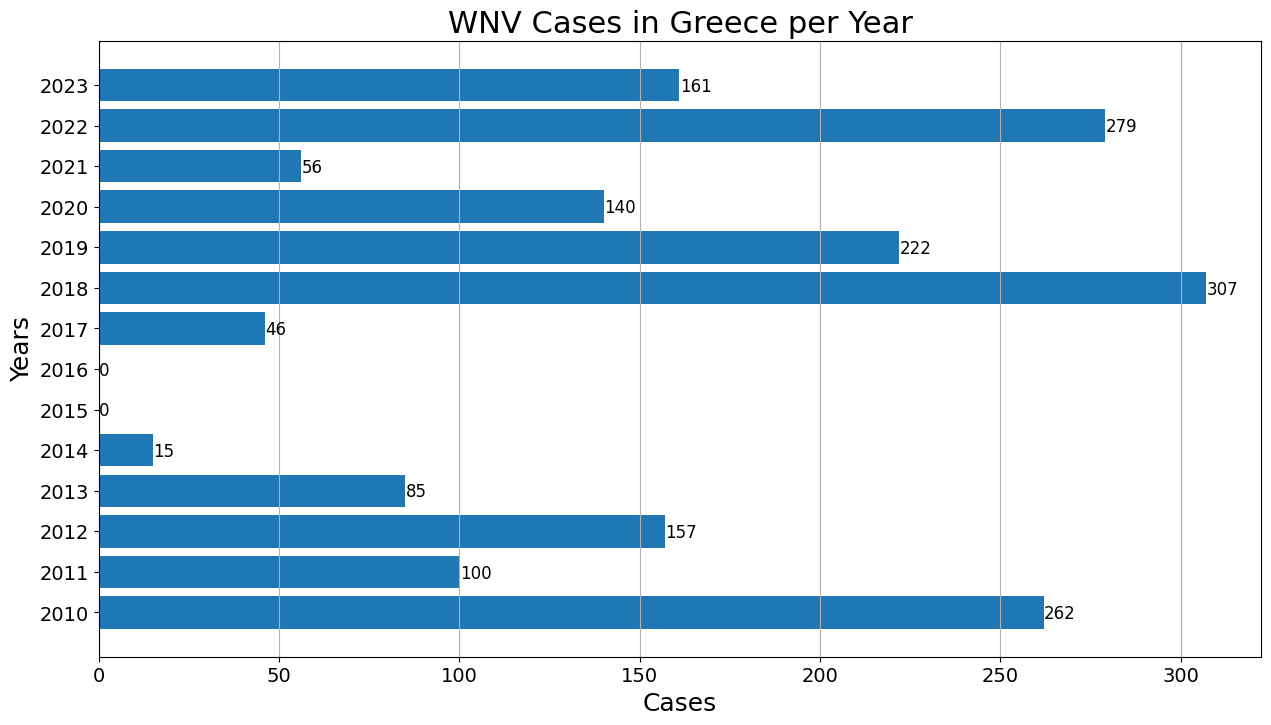

In [40]:
years = [year for year in range(2010, 2024)]
cases = [len(data.query(f"year == {year}")) for year in years]

plt.figure(num = None, figsize = (15,8), facecolor='w', edgecolor='b')
#plt.bar(years, cases)
plt.barh(years, cases)

#ax.bar_label(bars)
y_t = plt.xticks(np.arange(0, max(cases) + 10, step = 50), size = 14)
x_t = plt.yticks(np.arange(min(years), max(years) + 1, step = 1), size = 14)
x_l  = plt.ylabel('Years', size = 18)
y_l =  plt.xlabel('Cases', size = 18)
title = plt.title('WNV Cases in Greece per Year', size = 22)
for year, case in zip(years,cases):
    plt.text(case+0.15, year-0.15, str(case), size = 12)
ax = plt.gca()
ax.xaxis.grid(True)
plt.show()

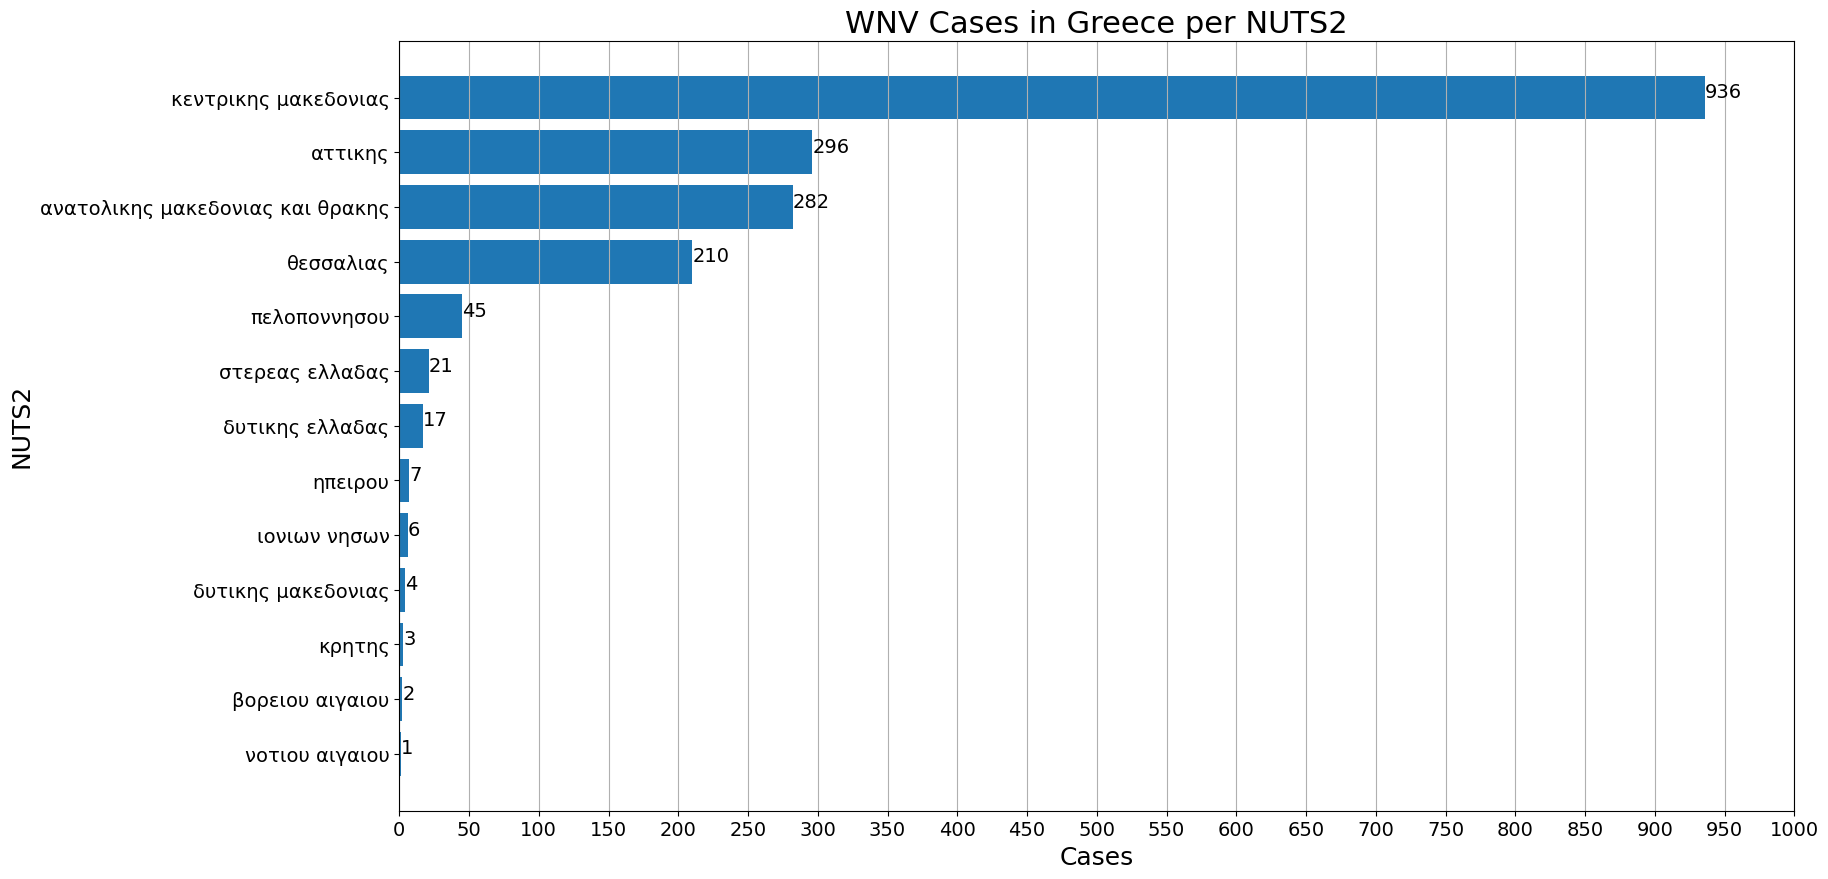

In [41]:
nuts2 = data['nuts2'].drop_duplicates().sort_values().tolist()
cases = [len(data.query(f"nuts2 == '{nuts2_unit}'")) for nuts2_unit in nuts2]

cases, nuts2 = zip(*sorted(zip(cases, nuts2)))

plt.figure(num = None, figsize = (18,10), facecolor='w', edgecolor='b')
plt.barh(nuts2, cases)

y_t = plt.xticks(np.arange(0, max(cases) + 100, step = 50), size = 14)
x_t = plt.yticks(nuts2, size = 14)
x_l  = plt.ylabel('NUTS2', size = 18)
y_l =  plt.xlabel('Cases', size = 18)
title = plt.title('WNV Cases in Greece per NUTS2', size = 22)
for nuts2, case in zip(nuts2,cases):
    plt.text(case+0.15, nuts2, str(case), size = 14)
ax = plt.gca()
ax.xaxis.grid(True)
plt.show()

In [45]:
data_until_2021 = data[data['year']<= 2021]

In [46]:
data_until_2021

,onset of symptoms,year,month,day,nuts2,nuts3,cases
0,2010-07-06,2010,7,6,κεντρικης μακεδονιας,σερρων,1
1,2010-07-16,2010,7,16,κεντρικης μακεδονιας,κιλκις,1
2,2010-07-18,2010,7,18,κεντρικης μακεδονιας,πελλας,1
3,2010-07-19,2010,7,19,κεντρικης μακεδονιας,θεσσαλονικης,1
4,2010-07-20,2010,7,20,κεντρικης μακεδονιας,ημαθιας,1
...,...,...,...,...,...,...,...
1801,2012-07-20,2012,7,20,αττικης,νοτιου τομεα αθηνων,1
1805,2012-07-20,2012,7,20,αττικης,νοτιου τομεα αθηνων,1
1809,2012-07-20,2012,7,20,αττικης,νοτιου τομεα αθηνων,1
1813,2012-07-20,2012,7,20,αττικης,νοτιου τομεα αθηνων,1


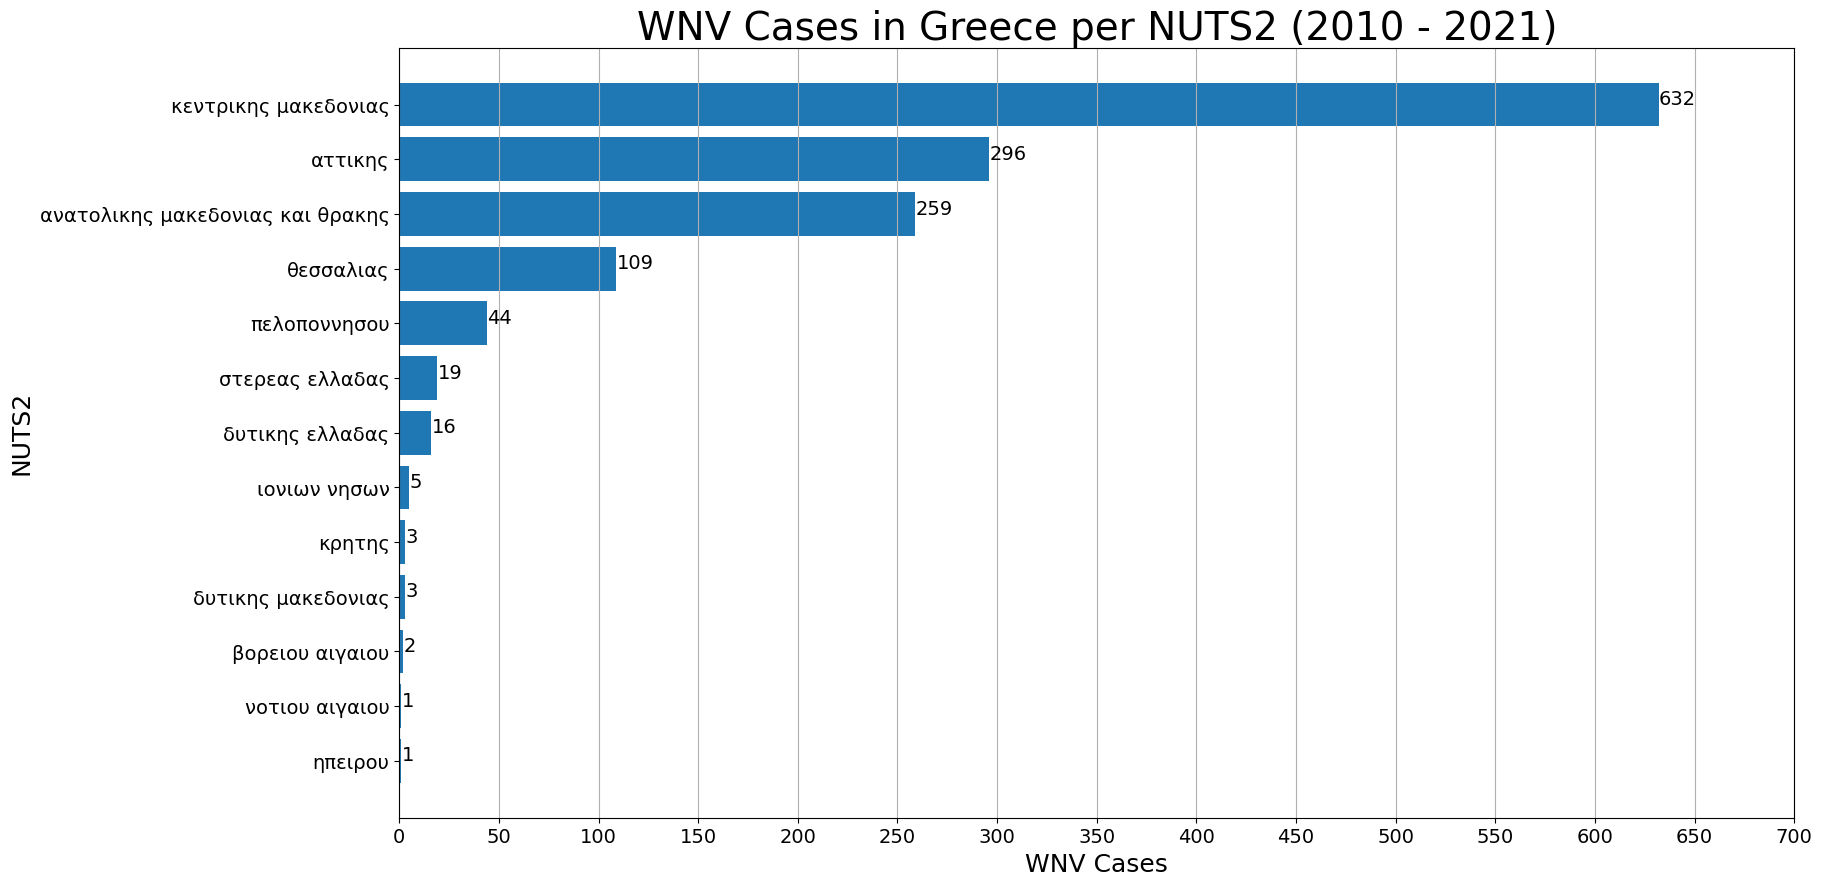

In [49]:
nuts2 = data_until_2021['nuts2'].drop_duplicates().sort_values().tolist()
cases = [len(data_until_2021.query(f"nuts2 == '{nuts2_unit}'")) for nuts2_unit in nuts2]

cases, nuts2 = zip(*sorted(zip(cases, nuts2)))

plt.figure(num = None, figsize = (18,10), facecolor='w', edgecolor='b')
plt.barh(nuts2, cases)

y_t = plt.xticks(np.arange(0, max(cases) + 100, step = 50), size = 14)
x_t = plt.yticks(nuts2, size = 14)
x_l  = plt.ylabel('NUTS2', size = 18)
y_l =  plt.xlabel('WNV Cases', size = 18)
title = plt.title('WNV Cases in Greece per NUTS2 (2010 - 2021)', size = 28)
for nuts2, case in zip(nuts2,cases):
    plt.text(case+0.15, nuts2, str(case), size = 14)
ax = plt.gca()
ax.xaxis.grid(True)
plt.show()

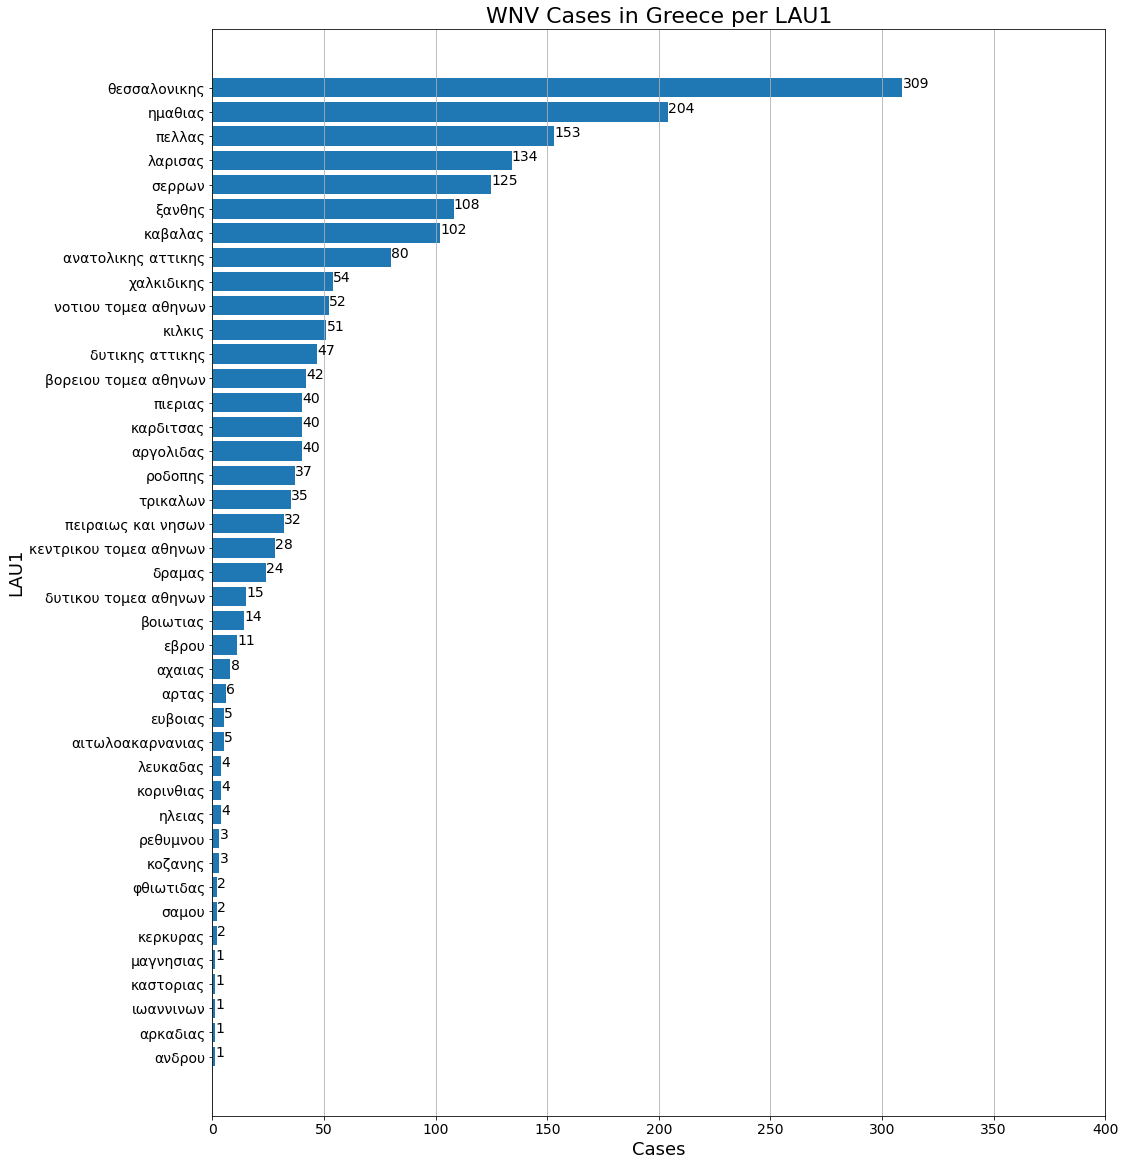

In [40]:
nuts3 = data['nuts3'].drop_duplicates().sort_values().tolist()
cases = [len(data.query(f"nuts3 == '{nuts2_unit}'")) for nuts2_unit in nuts3]

cases, nuts3 = zip(*sorted(zip(cases, nuts3)))

plt.figure(num = None, figsize = (16,20), facecolor='w', edgecolor='b')
plt.barh(nuts3, cases)

y_t = plt.xticks(np.arange(0, max(cases) + 100, step = 50), size = 14)
x_t = plt.yticks(nuts3, size = 14)
x_l  = plt.ylabel('LAU1', size = 18)
y_l =  plt.xlabel('Cases', size = 18)
title = plt.title('WNV Cases in Greece per LAU1', size = 22)
for nuts3, case in zip(nuts3,cases):
    plt.text(case+0.15, nuts3, str(case), size = 14)
ax = plt.gca()
ax.xaxis.grid(True)
plt.show()

In [41]:
cmacedonia = data.query(f"nuts2 == 'κεντρικης μακεδονιας'")
attica = data.query(f"nuts2 == 'αττικης'")
thrace = data.query(f"nuts2 == 'ανατολικης μακεδονιας και θρακης'")
thessaly = data.query(f"nuts2 == 'θεσσαλιας'")
combined = pd.concat([cmacedonia, attica, thrace, thessaly])

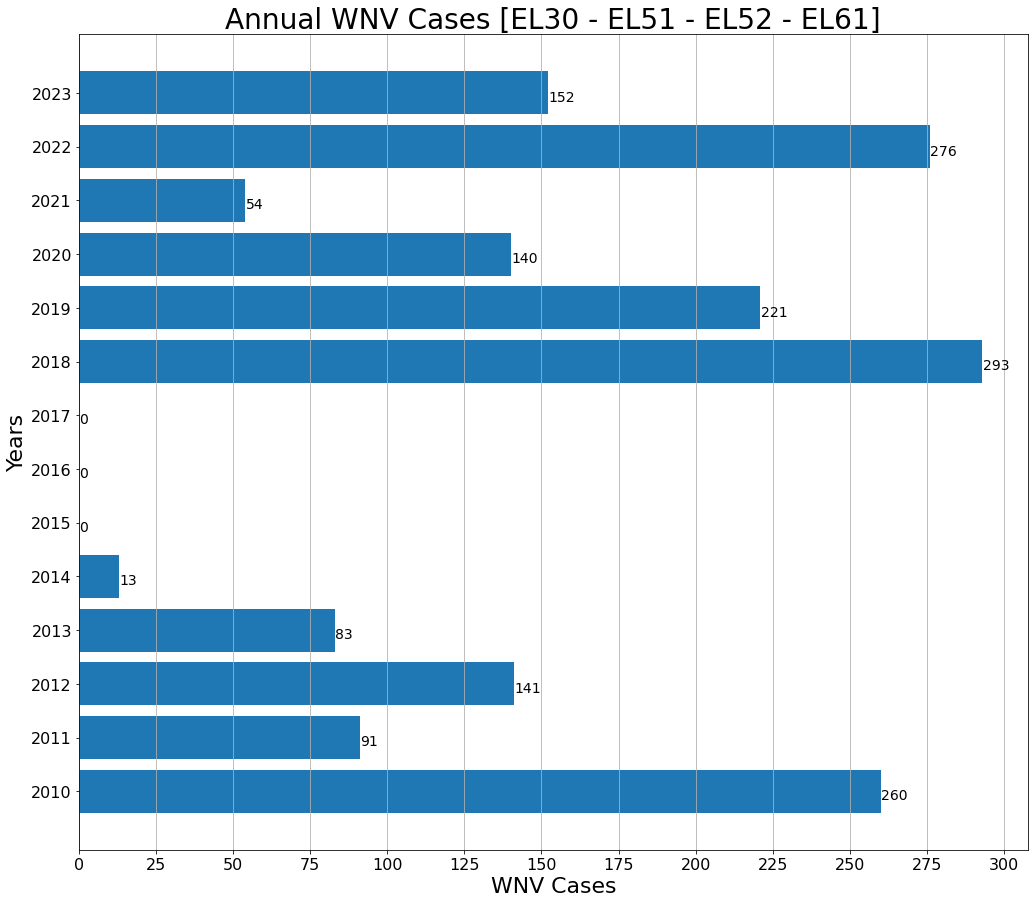

In [44]:
years = [year for year in range(2010, 2024)]
cases = [len(combined.query(f"year == {year}")) for year in years]

plt.figure(num = None, figsize = (17,15), facecolor='w', edgecolor='b')
#plt.bar(years, cases)
plt.barh(years, cases)

#ax.bar_label(bars)
y_t = plt.xticks(np.arange(0, max(cases) + 10, step = 25), size = 16)
x_t = plt.yticks(np.arange(min(years), max(years) + 1, step = 1), size = 16)
x_l  = plt.ylabel('Years', size = 22)
y_l =  plt.xlabel('WNV Cases', size = 22)
title = plt.title('Annual WNV Cases [EL30 - EL51 - EL52 - EL61]', size = 28)
for year, case in zip(years,cases):
    plt.text(case+0.15, year-0.15, str(case), size = 14)
ax = plt.gca()
ax.xaxis.grid(True)
plt.show()

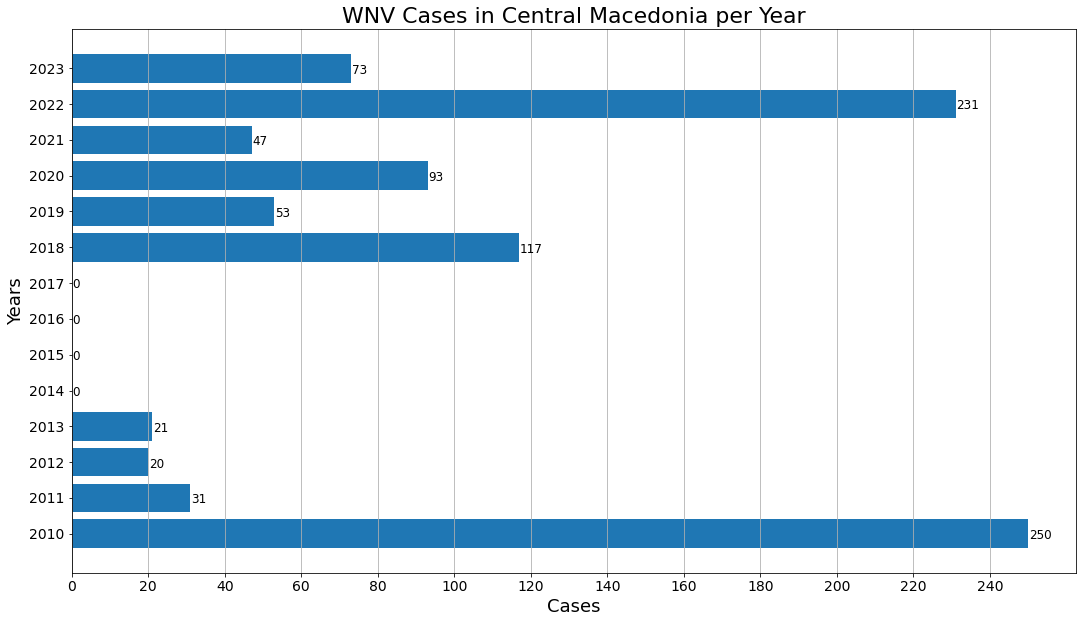

In [43]:
years = [year for year in range(2010, 2024)]
cases = [len(cmacedonia.query(f"year == {year}")) for year in years]

plt.figure(num = None, figsize = (18,10), facecolor='w', edgecolor='b')
#plt.bar(years, cases)
plt.barh(years, cases)

#ax.bar_label(bars)
y_t = plt.xticks(np.arange(0, max(cases) + 10, step = 20), size = 14)
x_t = plt.yticks(np.arange(min(years), max(years) + 1, step = 1), size = 14)
x_l  = plt.ylabel('Years', size = 18)
y_l =  plt.xlabel('Cases', size = 18)
title = plt.title('WNV Cases in Central Macedonia per Year', size = 22)
for year, case in zip(years,cases):
    plt.text(case+0.15, year-0.15, str(case), size = 12)
ax = plt.gca()
ax.xaxis.grid(True)
plt.show()

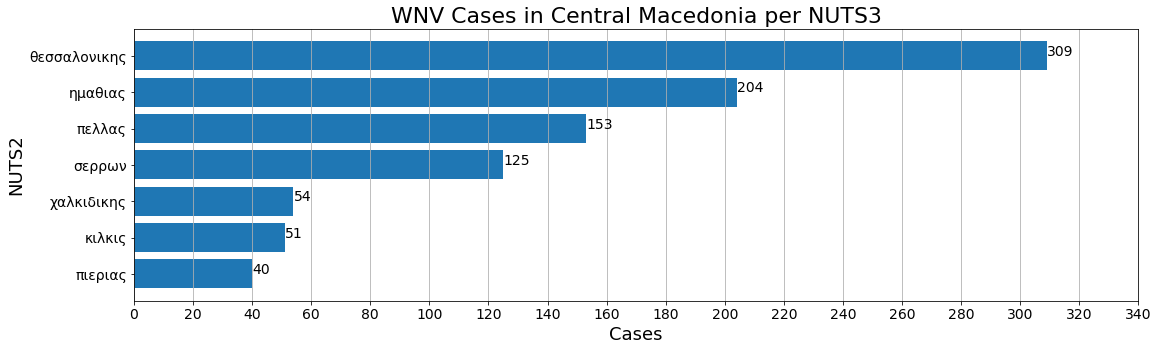

In [44]:
nuts3 = cmacedonia['nuts3'].drop_duplicates().sort_values().tolist()
cases = [len(data.query(f"nuts3 == '{nuts3_unit}'")) for nuts3_unit in nuts3]

cases, nuts3 = zip(*sorted(zip(cases, nuts3)))

plt.figure(num = None, figsize = (18,5), facecolor='w', edgecolor='b')
plt.barh(nuts3, cases)

y_t = plt.xticks(np.arange(0, max(cases) + 50, step = 20), size = 14)
x_t = plt.yticks(nuts3, size = 14)
x_l  = plt.ylabel('NUTS2', size = 18)
y_l =  plt.xlabel('Cases', size = 18)
title = plt.title('WNV Cases in Central Macedonia per NUTS3', size = 22)
for nuts3, case in zip(nuts3,cases):
    plt.text(case+0.15, nuts3, str(case), size = 14)
ax = plt.gca()
ax.xaxis.grid(True)
plt.show()

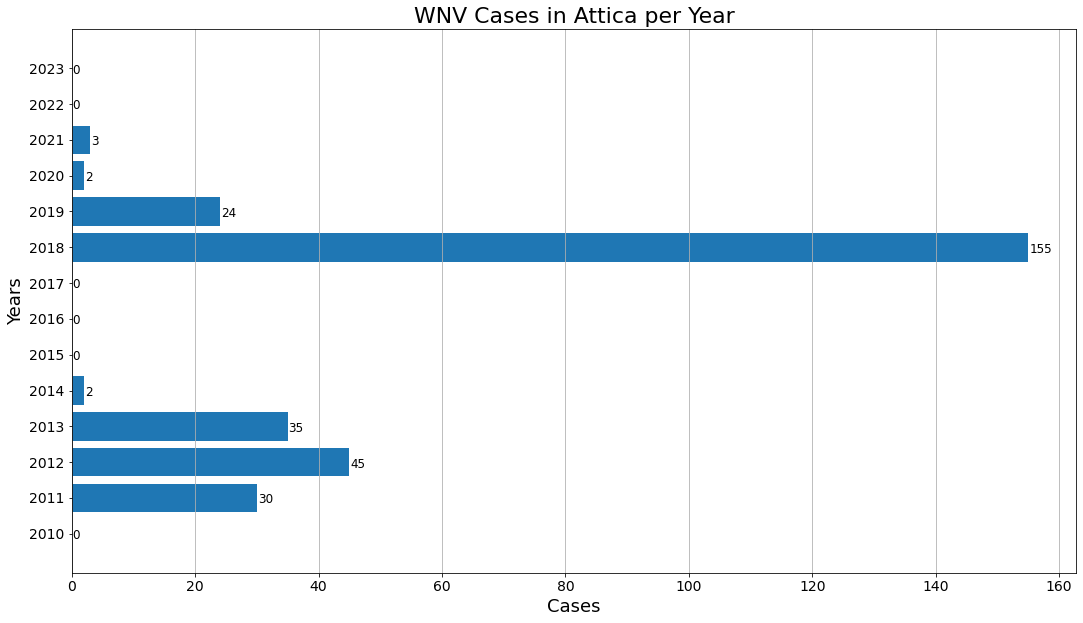

In [45]:
years = [year for year in range(2010, 2024)]
cases = [len(attica.query(f"year == {year}")) for year in years]

plt.figure(num = None, figsize = (18,10), facecolor='w', edgecolor='b')
#plt.bar(years, cases)
plt.barh(years, cases)

#ax.bar_label(bars)
y_t = plt.xticks(np.arange(0, max(cases) + 10, step = 20), size = 14)
x_t = plt.yticks(np.arange(min(years), max(years) + 1, step = 1), size = 14)
x_l  = plt.ylabel('Years', size = 18)
y_l =  plt.xlabel('Cases', size = 18)
title = plt.title('WNV Cases in Attica per Year', size = 22)
for year, case in zip(years,cases):
    plt.text(case+0.15, year-0.15, str(case), size = 12)
ax = plt.gca()
ax.xaxis.grid(True)
plt.show()

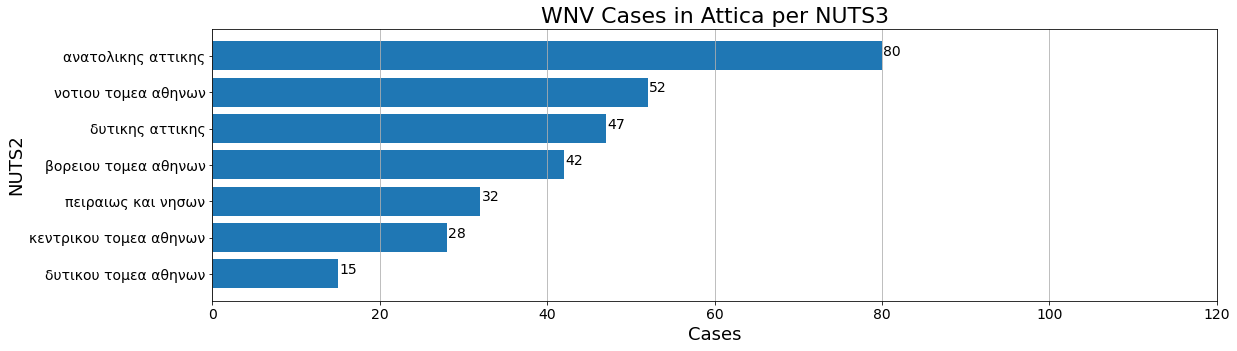

In [46]:
nuts3 = attica['nuts3'].drop_duplicates().sort_values().tolist()
cases = [len(data.query(f"nuts3 == '{nuts3_unit}'")) for nuts3_unit in nuts3]

cases, nuts3 = zip(*sorted(zip(cases, nuts3)))

plt.figure(num = None, figsize = (18,5), facecolor='w', edgecolor='b')
plt.barh(nuts3, cases)

y_t = plt.xticks(np.arange(0, max(cases) + 50, step = 20), size = 14)
x_t = plt.yticks(nuts3, size = 14)
x_l  = plt.ylabel('NUTS2', size = 18)
y_l =  plt.xlabel('Cases', size = 18)
title = plt.title('WNV Cases in Attica per NUTS3', size = 22)
for nuts3, case in zip(nuts3,cases):
    plt.text(case+0.15, nuts3, str(case), size = 14)
ax = plt.gca()
ax.xaxis.grid(True)
plt.show()

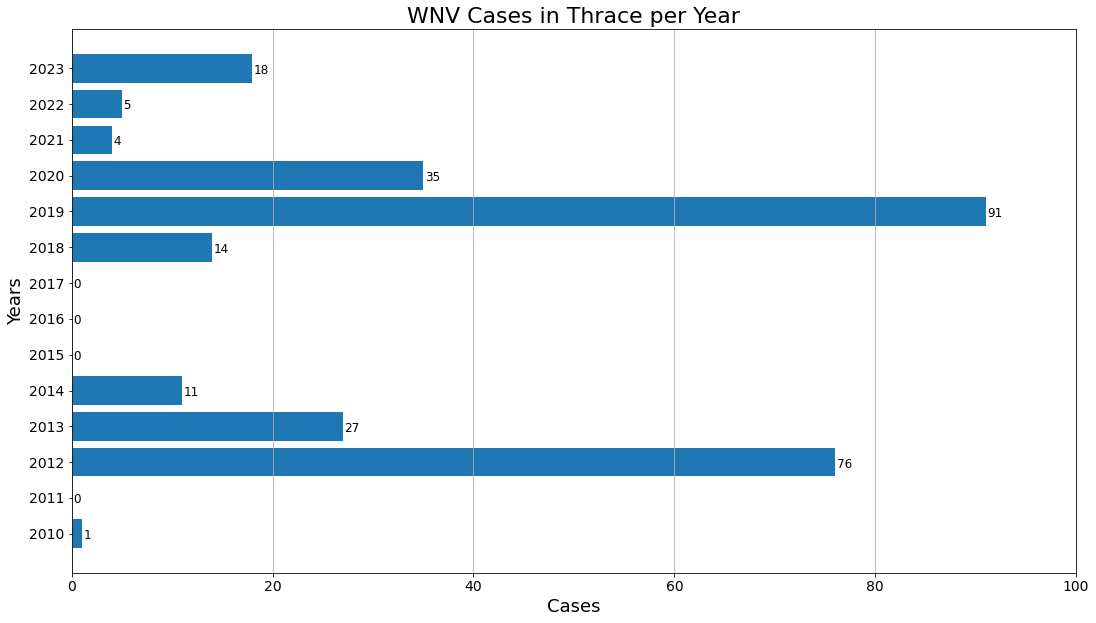

In [47]:
years = [year for year in range(2010, 2024)]
cases = [len(thrace.query(f"year == {year}")) for year in years]

plt.figure(num = None, figsize = (18,10), facecolor='w', edgecolor='b')
#plt.bar(years, cases)
plt.barh(years, cases)

#ax.bar_label(bars)
y_t = plt.xticks(np.arange(0, max(cases) + 10, step = 20), size = 14)
x_t = plt.yticks(np.arange(min(years), max(years) + 1, step = 1), size = 14)
x_l  = plt.ylabel('Years', size = 18)
y_l =  plt.xlabel('Cases', size = 18)
title = plt.title('WNV Cases in Thrace per Year', size = 22)
for year, case in zip(years,cases):
    plt.text(case+0.15, year-0.15, str(case), size = 12)
ax = plt.gca()
ax.xaxis.grid(True)
plt.show()

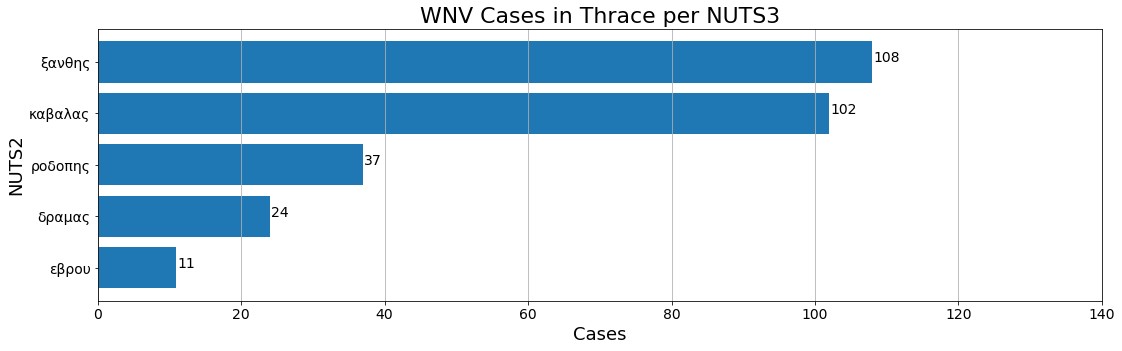

In [48]:
nuts3 = thrace['nuts3'].drop_duplicates().sort_values().tolist()
cases = [len(data.query(f"nuts3 == '{nuts3_unit}'")) for nuts3_unit in nuts3]

cases, nuts3 = zip(*sorted(zip(cases, nuts3)))

plt.figure(num = None, figsize = (18,5), facecolor='w', edgecolor='b')
plt.barh(nuts3, cases)

y_t = plt.xticks(np.arange(0, max(cases) + 50, step = 20), size = 14)
x_t = plt.yticks(nuts3, size = 14)
x_l  = plt.ylabel('NUTS2', size = 18)
y_l =  plt.xlabel('Cases', size = 18)
title = plt.title('WNV Cases in Thrace per NUTS3', size = 22)
for nuts3, case in zip(nuts3,cases):
    plt.text(case+0.15, nuts3, str(case), size = 14)
ax = plt.gca()
ax.xaxis.grid(True)
plt.show()

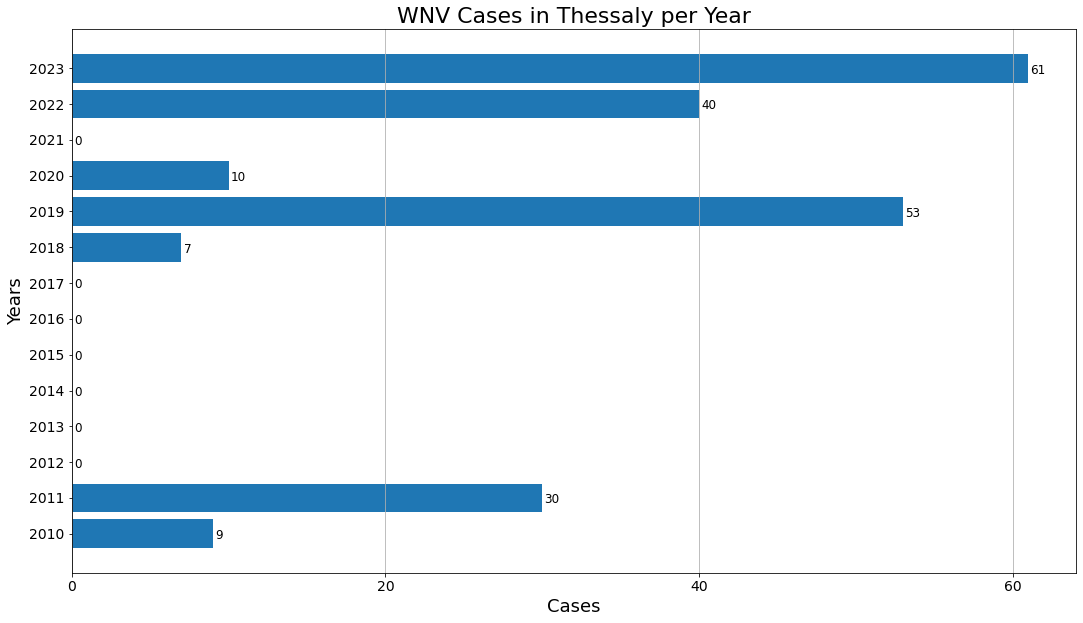

In [49]:
years = [year for year in range(2010, 2024)]
cases = [len(thessaly.query(f"year == {year}")) for year in years]

plt.figure(num = None, figsize = (18,10), facecolor='w', edgecolor='b')
#plt.bar(years, cases)
plt.barh(years, cases)

#ax.bar_label(bars)
y_t = plt.xticks(np.arange(0, max(cases) + 10, step = 20), size = 14)
x_t = plt.yticks(np.arange(min(years), max(years) + 1, step = 1), size = 14)
x_l  = plt.ylabel('Years', size = 18)
y_l =  plt.xlabel('Cases', size = 18)
title = plt.title('WNV Cases in Thessaly per Year', size = 22)
for year, case in zip(years,cases):
    plt.text(case+0.15, year-0.15, str(case), size = 12)
ax = plt.gca()
ax.xaxis.grid(True)
plt.show()

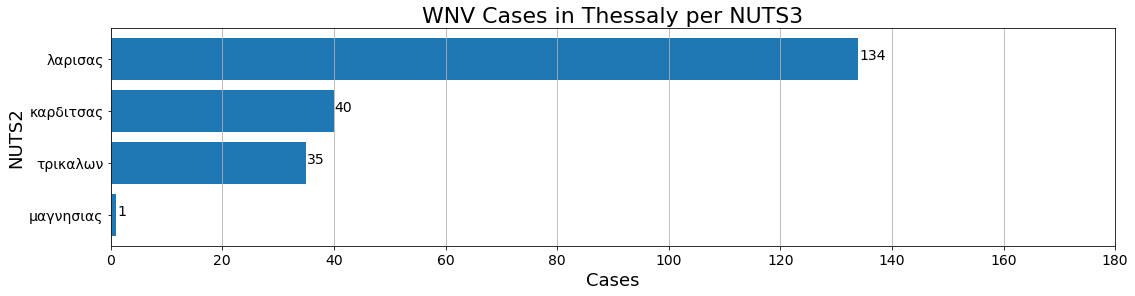

In [50]:
nuts3 = thessaly['nuts3'].drop_duplicates().sort_values().tolist()
cases = [len(data.query(f"nuts3 == '{nuts3_unit}'")) for nuts3_unit in nuts3]

cases, nuts3 = zip(*sorted(zip(cases, nuts3)))

plt.figure(num = None, figsize = (18,4), facecolor='w', edgecolor='b')
plt.barh(nuts3, cases)

y_t = plt.xticks(np.arange(0, max(cases) + 50, step = 20), size = 14)
x_t = plt.yticks(nuts3, size = 14)
x_l  = plt.ylabel('NUTS2', size = 18)
y_l =  plt.xlabel('Cases', size = 18)
title = plt.title('WNV Cases in Thessaly per NUTS3', size = 22)
for nuts3, case in zip(nuts3,cases):
    plt.text(case+0.15, nuts3, str(case), size = 14)
ax = plt.gca()
ax.xaxis.grid(True)
plt.show()